In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind  # corrected function
import scipy.stats as stats  

# Ignore all warnings
warnings.filterwarnings('ignore')

In [6]:
conn=sqlite3.connect('inventory.db')

df=pd.read_sql_query("select* from vendor_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,0,0,0,0,27.08,-190.88,-inf,0.0,0.0
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,0,0,0,0,27.08,-5440.00,-inf,0.0,0.0
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750.0,1,105.07,0,0,0,0,0.48,-105.07,-inf,0.0,0.0
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,0,0,0,0,367.52,-446.16,-inf,0.0,0.0
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750.0,6,66.60,0,0,0,0,367.52,-66.60,-inf,0.0,0.0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.9900,15.990,28.9900,7499.99
Volume,10692.0,8.473605e+02,664.309212,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesQuantity,10692.0,0.000000e+00,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesDollars,10692.0,0.000000e+00,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesPrice,10692.0,0.000000e+00,0.000000,0.00,0.0000,0.000,0.0000,0.00


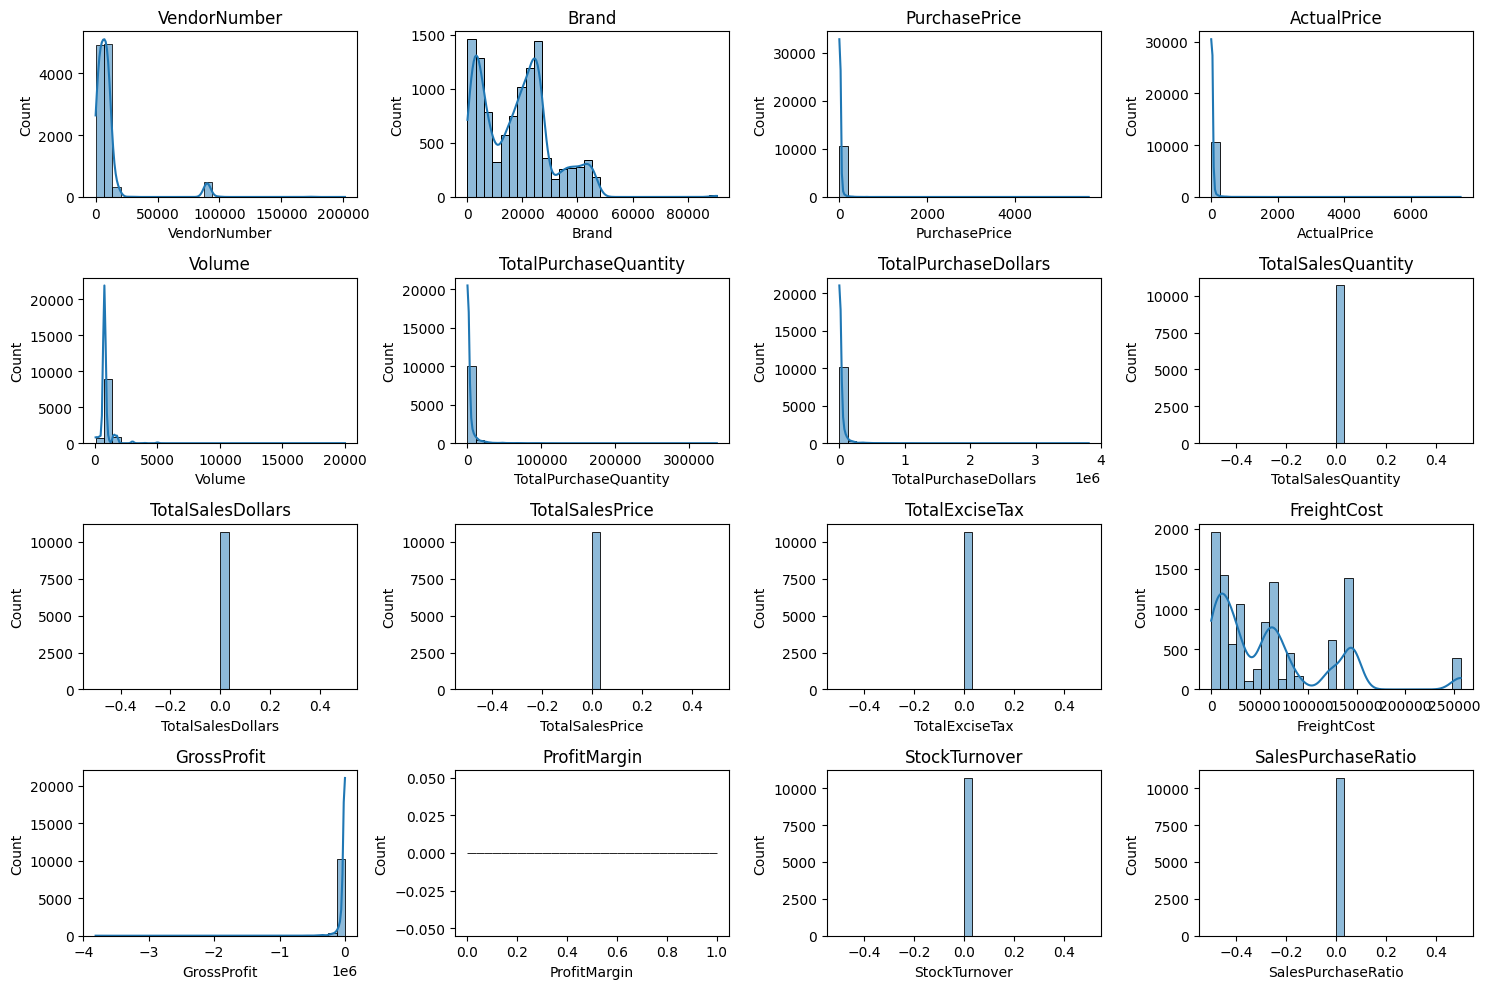

In [9]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
    plt.tight_layout()
plt.show()

In [10]:
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

In [11]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.331591,2.250000,3.488160
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.672675,1.205128,1.579097
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12.0,359.88,59.98,9.44,62.39,80.88,22.474158,1.000000,1.289892
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,25.540808,0.959375,1.343018
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84.0,1511.16,287.84,9.43,6.19,577.08,38.187882,0.875000,1.617806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,375.0,138,2028.60,125.0,2498.75,1819.09,49.00,178.34,470.15,18.815408,0.905797,1.231761
8561,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,750.0,267,5732.49,222.0,6435.78,5363.15,175.13,178.34,703.29,10.927813,0.831461,1.122685
8562,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750.0,554,11955.32,452.0,12877.48,8205.12,356.14,178.34,922.16,7.161028,0.815884,1.077134
8563,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750.0,1232,23863.84,982.0,24540.18,14469.21,773.87,202.50,676.34,2.756052,0.797078,1.028342


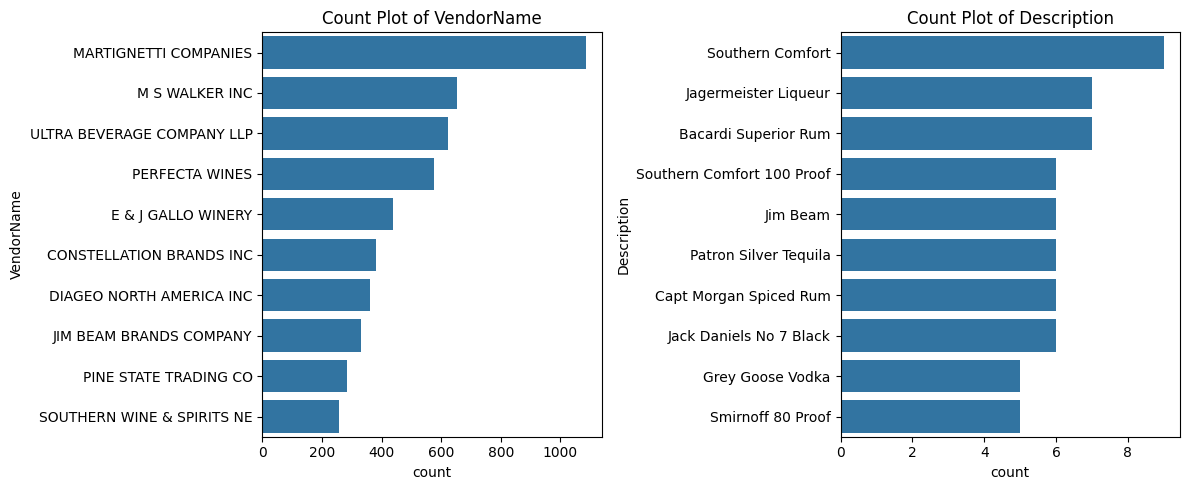

In [12]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

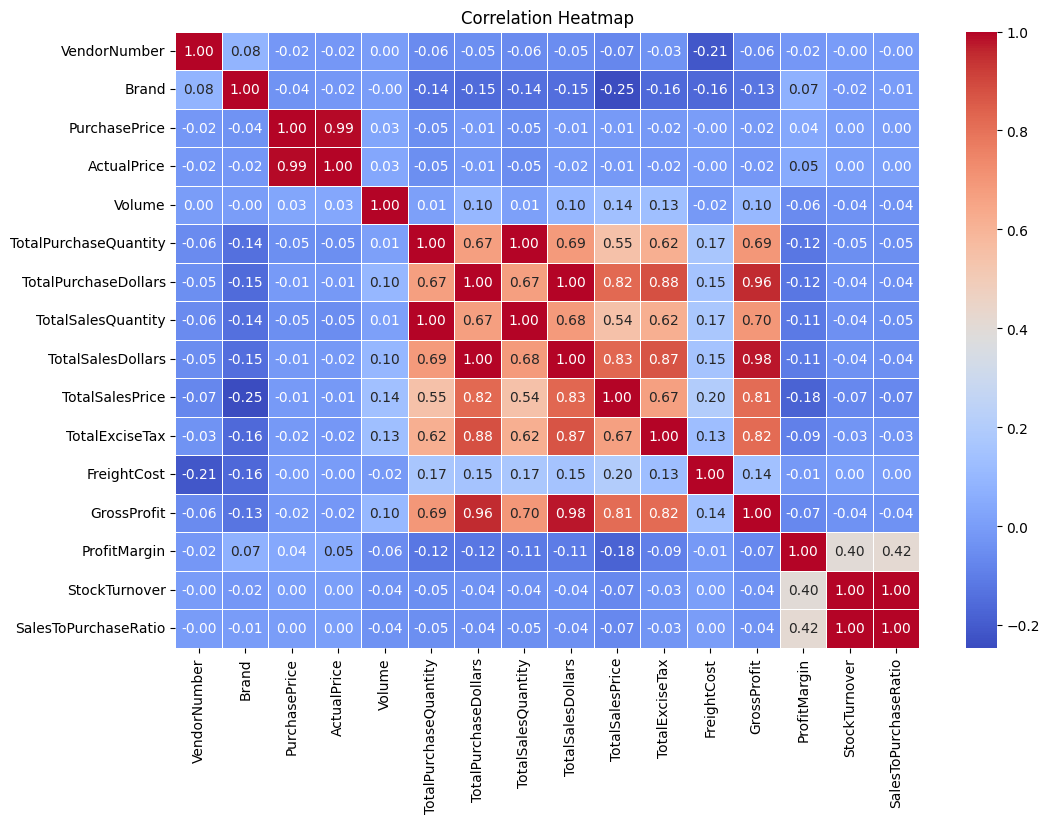

In [17]:
# Recalculate numerical columns for the current df
numerical_cols = df.select_dtypes(include=np.number).columns

# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [19]:
low_sales_threshold

560.299

In [20]:
high_margin_threshold

64.97017552750111

In [21]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [24]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 1000]

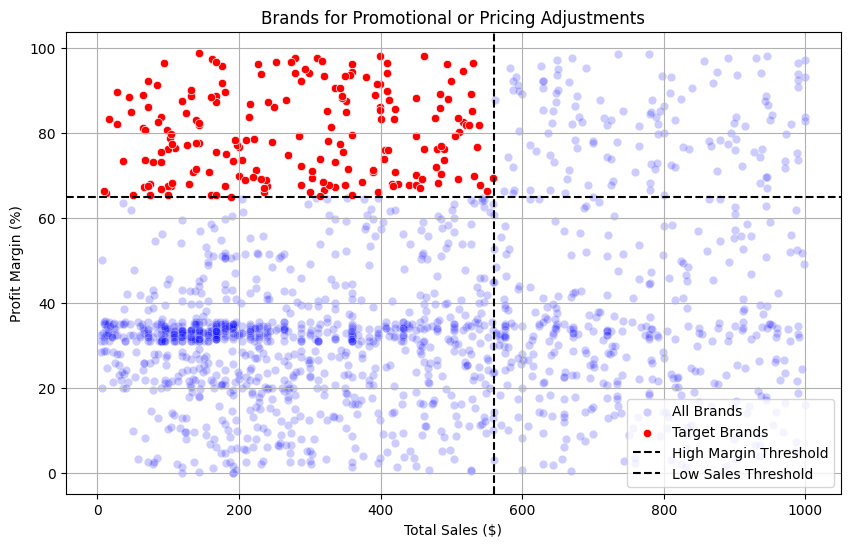

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [28]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [39]:
def format_dollars(x):
    try:
        return "${:,.2f}".format(float(x))
    except (ValueError, TypeError):
        return x  # if it can't be converted, leave it as-is

# Make sure top_brands is a DataFrame
top_brands = df[['VendorName', 'Brand', 'TotalSalesDollars']]

# Apply formatting
top_brands['TotalSalesDollars'] = top_brands['TotalSalesDollars'].apply(format_dollars)

top_brands.head()

,VendorName,Brand,TotalSalesDollars
0,"IRA GOLDMAN AND WILLIAMS, LLP",90085,$665.82
1,ADAMBA IMPORTS INTL INC,771,$704.53
2,ALTAMAR BRANDS LLC,2529,$359.88
3,ALTAMAR BRANDS LLC,8412,"$15,346.93"
4,AMERICAN SPIRITS EXCHANGE,20789,"$1,511.16"


In [46]:
# Convert to numeric, coercing errors to NaN
top_brands['TotalSalesDollars'] = pd.to_numeric(top_brands['TotalSalesDollars'], errors='coerce')

# Now apply formatting
top_brands['TotalSalesDollars'] = top_brands['TotalSalesDollars'].apply(lambda x: f"${x:,.2f}" if pd.notnull(x) else "$0.00")

In [45]:
print(top_brands.head())
print(top_brands.shape)

                      VendorName  Brand TotalSalesDollars  \
0  IRA GOLDMAN AND WILLIAMS, LLP  90085             $0.00   
1        ADAMBA IMPORTS INTL INC    771             $0.00   
2             ALTAMAR BRANDS LLC   2529             $0.00   
3             ALTAMAR BRANDS LLC   8412             $0.00   
4      AMERICAN SPIRITS EXCHANGE  20789             $0.00   

   TotalSalesDollars_numeric  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  
(8565, 4)


In [47]:
# Remove any formatting and convert to numeric
top_brands['TotalSalesDollars_numeric'] = pd.to_numeric(top_brands['TotalSalesDollars'], errors='coerce')

# Check for NaN
print(top_brands[['TotalSalesDollars', 'TotalSalesDollars_numeric']].head())

  TotalSalesDollars  TotalSalesDollars_numeric
0             $0.00                        NaN
1             $0.00                        NaN
2             $0.00                        NaN
3             $0.00                        NaN
4             $0.00                        NaN


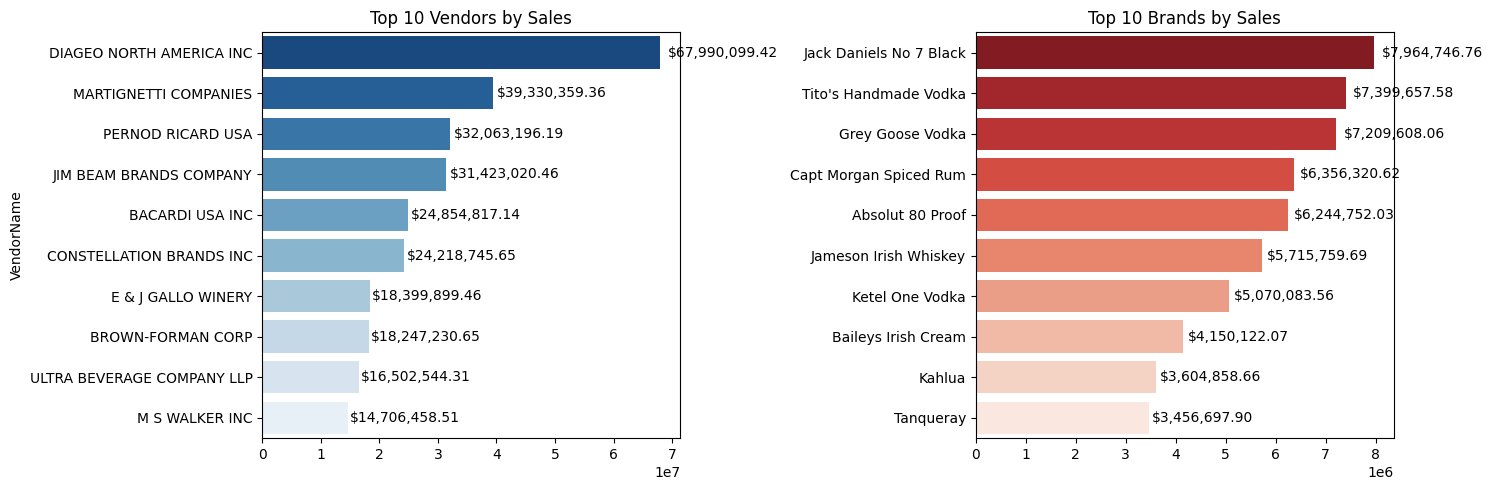

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Top 10 Vendors ---
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

# --- Top 10 Brands ---
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10).reset_index()

# Create numeric column for plotting
top_brands['TotalSalesDollars_numeric'] = top_brands['TotalSalesDollars']

# --- Plot ---
plt.figure(figsize=(15, 5))

# Plot Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index.astype(str),
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.2f}",
        ha='left', va='center', fontsize=10, color='black'
    )

# Plot Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands['Description'].values,  # ✅ This column now exists
    x=top_brands['TotalSalesDollars_numeric'].values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.2f}",
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

In [55]:
# Aggregate vendor performance
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

# Calculate purchase contribution percentage
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum() * 100
)

# Optional: sort by purchase contribution
vendor_performance = vendor_performance.sort_values('PurchaseContribution%', ascending=False)

# Show top 10 vendors by contribution
vendor_performance.head(10)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,1.789287e+07,6.799010e+07,16.300334
57,MARTIGNETTI COMPANIES,25502095.83,1.382826e+07,3.933036e+07,8.297719
68,PERNOD RICARD USA,23851164.17,8.212032e+06,3.206320e+07,7.760548
46,JIM BEAM BRANDS COMPANY,23494304.32,7.928716e+06,3.142302e+07,7.644435
6,BACARDI USA INC,17432020.26,7.422797e+06,2.485482e+07,5.671926
20,CONSTELLATION BRANDS INC,15273708.08,8.945038e+06,2.421875e+07,4.969667
11,BROWN-FORMAN CORP,13238939.18,5.008291e+06,1.824723e+07,4.307606
30,E & J GALLO WINERY,12068539.22,6.331360e+06,1.839990e+07,3.926789
106,ULTRA BEVERAGE COMPANY LLP,11167081.61,5.335463e+06,1.650254e+07,3.633478
53,M S WALKER INC,9764312.60,4.942146e+06,1.470646e+07,3.177053


In [56]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226.16","$17,892,873.26","$67,990,099.42",16.300334
57,MARTIGNETTI COMPANIES,"$25,502,095.83","$13,828,263.53","$39,330,359.36",8.297719
68,PERNOD RICARD USA,"$23,851,164.17","$8,212,032.02","$32,063,196.19",7.760548
46,JIM BEAM BRANDS COMPANY,"$23,494,304.32","$7,928,716.14","$31,423,020.46",7.644435
6,BACARDI USA INC,"$17,432,020.26","$7,422,796.88","$24,854,817.14",5.671926
20,CONSTELLATION BRANDS INC,"$15,273,708.08","$8,945,037.57","$24,218,745.65",4.969667
11,BROWN-FORMAN CORP,"$13,238,939.18","$5,008,291.47","$18,247,230.65",4.307606
30,E & J GALLO WINERY,"$12,068,539.22","$6,331,360.24","$18,399,899.46",3.926789
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,081.61","$5,335,462.70","$16,502,544.31",3.633478
53,M S WALKER INC,"$9,764,312.60","$4,942,145.91","$14,706,458.51",3.177053


In [60]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()

In [63]:
print(top_vendors.columns)

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%'],
      dtype='object')


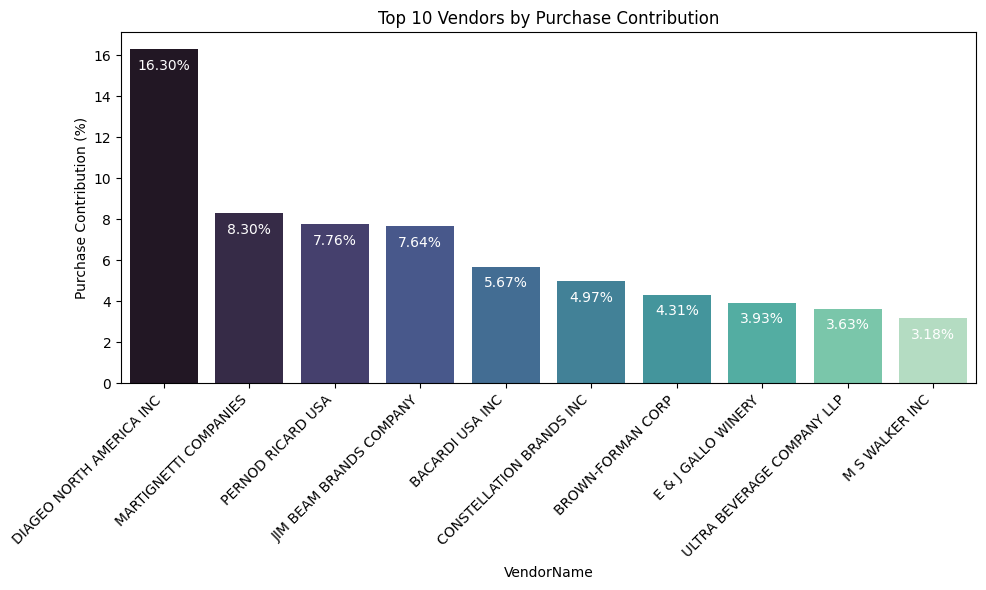

In [64]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution
sns.barplot(
    x='VendorName',
    y='PurchaseContribution%',
    data=top_vendors,
    palette="mako",
    ax=ax1
)

# Add value labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, f"{value:.2f}%", ha='center', fontsize=10, color='white')

plt.title("Top 10 Vendors by Purchase Contribution")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Purchase Contribution (%)")
plt.tight_layout()
plt.show()

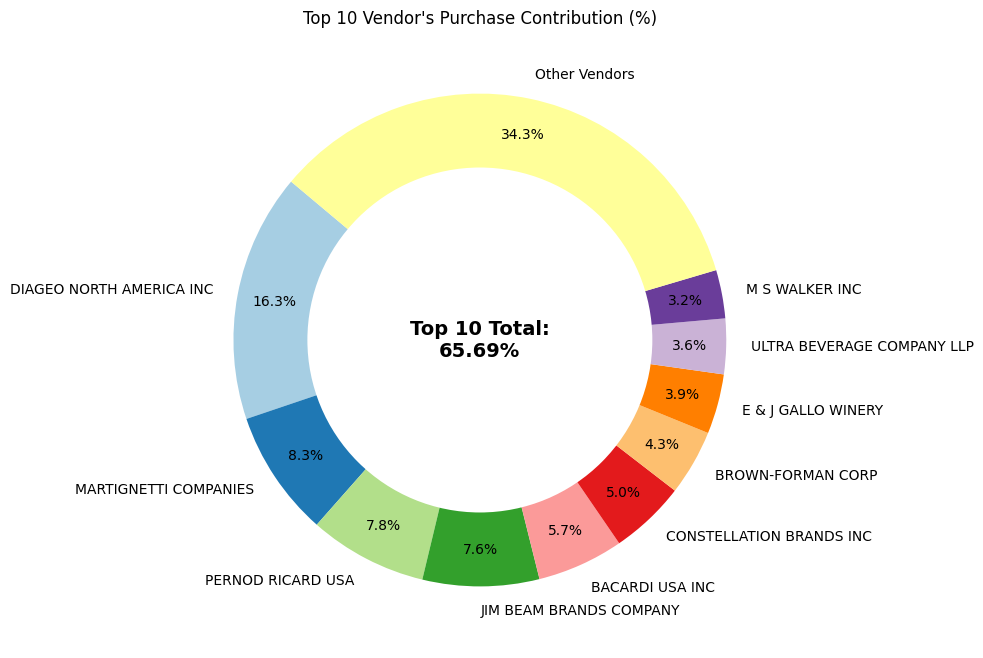

In [67]:
# Correct column name
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)  # ✅ correct

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [68]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.331591,2.250000,3.488160,23.86
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.672675,1.205128,1.579097,11.44
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12.0,359.88,59.98,9.44,62.39,80.88,22.474158,1.000000,1.289892,23.25
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,25.540808,0.959375,1.343018,35.71
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84.0,1511.16,287.84,9.43,6.19,577.08,38.187882,0.875000,1.617806,9.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,375.0,138,2028.60,125.0,2498.75,1819.09,49.00,178.34,470.15,18.815408,0.905797,1.231761,14.70
8561,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,750.0,267,5732.49,222.0,6435.78,5363.15,175.13,178.34,703.29,10.927813,0.831461,1.122685,21.47
8562,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750.0,554,11955.32,452.0,12877.48,8205.12,356.14,178.34,922.16,7.161028,0.815884,1.077134,21.58
8563,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750.0,1232,23863.84,982.0,24540.18,14469.21,773.87,202.50,676.34,2.756052,0.797078,1.028342,19.37


In [69]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [72]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Small,8
1,Small,39
2,Small,12
3,Medium,320
4,Medium,96
...,...,...
8560,Medium,138
8561,Medium,267
8562,Medium,554
8563,Medium,1232


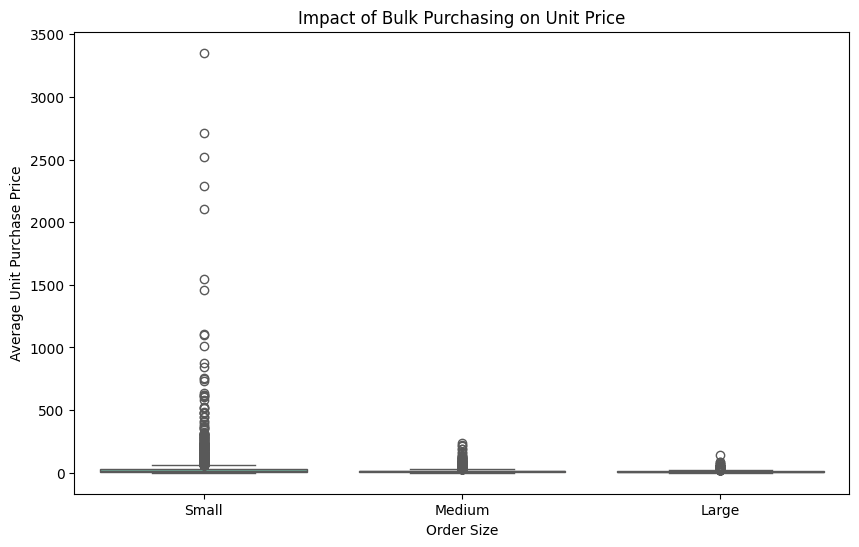

In [73]:
df.groupby("OrderSize")["UnitPurchasePrice"].mean()

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x="OrderSize", y="UnitPurchasePrice", data=df, palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [79]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [80]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print("Total Unsold Capital:", format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: $2,708,246.50


In [81]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,"$722,209.05"
46,JIM BEAM BRANDS COMPANY,"$554,665.63"
68,PERNOD RICARD USA,"$470,625.61"
116,WILLIAM GRANT & SONS INC,"$401,960.83"
30,E & J GALLO WINERY,"$228,282.61"
79,SAZERAC CO INC,"$198,436.41"
11,BROWN-FORMAN CORP,"$177,733.74"
20,CONSTELLATION BRANDS INC,"$133,617.62"
61,MOET HENNESSY USA INC,"$126,477.70"
77,REMY COINTREAU USA INC,"$118,598.15"


In [82]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

top_vendors

5       16.999601
8       30.557678
13      30.827478
14      27.129385
17      24.329082
          ...    
8537    25.173464
8538    22.886164
8539    22.652408
8553    27.103538
8555    28.056879
Name: ProfitMargin, Length: 2142, dtype: float64

In [83]:
low_vendors

0       71.331591
1       36.672675
2       22.474158
9       20.559532
10      64.915236
          ...    
8550    41.388657
8551    21.862972
8552    73.338465
8554    40.470235
8557    88.098999
Name: ProfitMargin, Length: 2142, dtype: float64

In [84]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


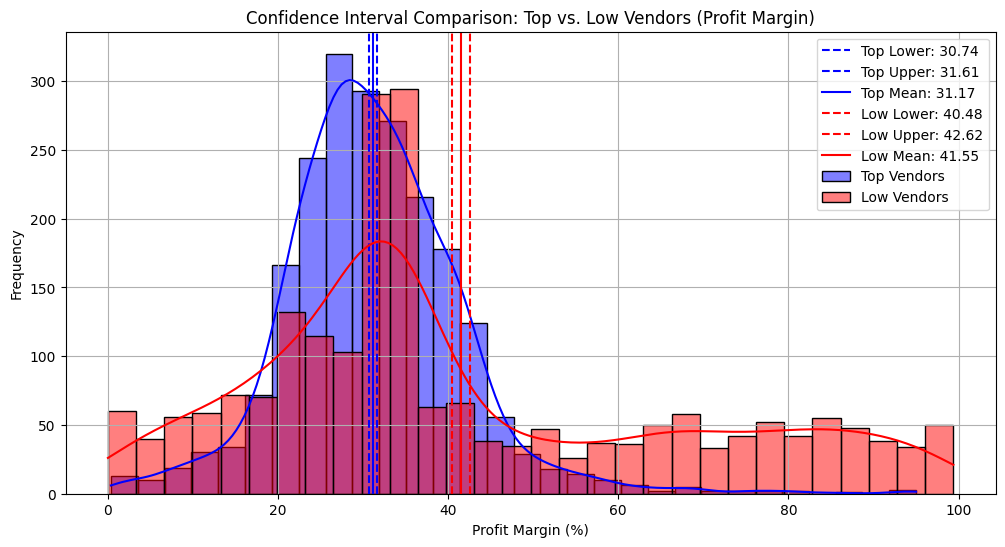

In [85]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6440, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
